initializing ocelot...


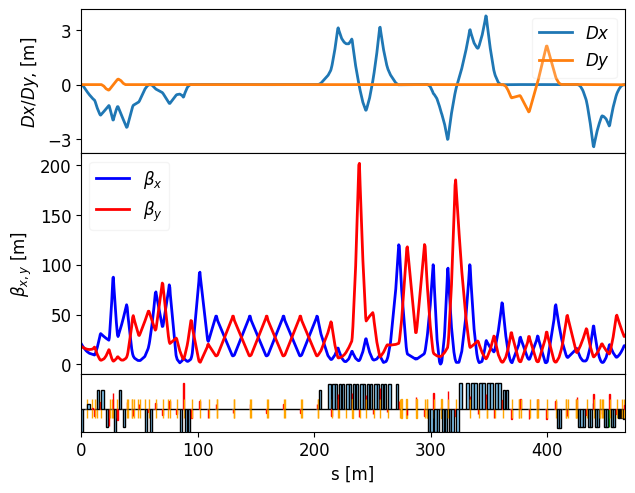

In [1]:
from ocelot import *
from ocelot.cpbd.elements import *
from ocelot.gui.accelerator import *
from ocelot.cpbd.track import track_debug
import matplotlib.pyplot as plt


from bte import *

#lat = MagneticLattice(lattice_list[0:380])
#lat = MagneticLattice(lattice_list[320:540])
lat = MagneticLattice(lattice_list)


energy = 7 # GeV  #why?
tw0 = Twiss()
tw0.alpha_x = AX
tw0.beta_x = BX

tw0.alpha_y = AY
tw0.beta_y = BY
tw0.E = energy
tw0.emit_xn = EMITX 
tw0.emit_yn = EMITY
tw0.emit_x = EMITX   / energy * 0.511e-3
tw0.emit_y = EMITY / energy * 0.511e-3

tws = twiss(lat,tw0)

plot_opt_func(lat, tws,legend=False, grid=False, top_plot=['Dx','Dy'])

In [2]:
_logger = logging.getLogger(__name__)

class ISRBend(PhysProc):
    """
    Incoherent Synchrotron Radiation (ISR) effects in dipoles:
    - Classical energy loss
    - Quantum energy diffusion (causes emittance growth)
    """

    def __init__(self, radius, step=1):
        super().__init__(step=step)
        self.radius = radius  # bending radius [m]
        self.type = "dipole"
        self.energy_loss = True
        self.quant_diff = True
        self.filling_coeff = 1.0

    def apply(self, p_array, dz):
        if self.type != "dipole":
            raise ValueError("ISRBend only supports type='dipole'")

        _logger.debug("ISRBend (dipole ISR) applied")

        mean_p = np.mean(p_array.p())             # relative momentum
        energy = p_array.E * (1 + mean_p)         # total energy [GeV]
        gamma = energy / m_e_GeV

        rho = self.radius

        # --- Apply Quantum Diffusion (energy spread) ---
        if self.quant_diff:
            sigma_E = self.quantum_diffusion(gamma, dz, rho)  # [GeV]
            dE = sigma_E * np.random.randn(p_array.n)         # [GeV]
            p_array.p()[:] += dE / energy * self.filling_coeff  # relative momentum change

        # --- Apply Energy Loss (classical) ---
        if self.energy_loss:
            dE_loss = self.classical_energy_loss(energy, dz, rho)  # [GeV]
            p_array.p()[:] -= dE_loss / energy * self.filling_coeff

    def classical_energy_loss(self, E, ds, rho):
        """From PDG: dE/ds = Cγ/(2π) * E⁴ / ρ²"""
        C_gamma = 8.846e-5  # m/GeV³
        return (C_gamma / (2 * np.pi)) * (E ** 4) / (rho ** 2) * ds

    def quantum_diffusion(self, gamma, ds, rho):
        """σ_E² = (55 / 24√3) * λ_c * r_e * γ⁷ * ds / ρ³"""
        lambda_c = h_eV_s / (m_e_eV * speed_of_light)  # [m] ≈ 3.86e-13
        r_e = ro_e                                    # classical electron radius ≈ 2.82e-15 m

        const = 55 / (24 * np.sqrt(3))
        sigma_E2 = const * lambda_c * r_e * gamma ** 7 * ds / rho ** 3
        return np.sqrt(sigma_E2)  # [GeV] 


In [3]:
import pickle

# Load the full ParticleArray (including rparticles, q_array, energy, etc.)
with open("p_array_t_LINAC.pkl", "rb") as f:
    p_array = pickle.load(f)

#  confirm:
print("Number of particles loaded:", p_array.n)
print("Beam energy [GeV]:", p_array.E)




Number of particles loaded: 100000
Beam energy [GeV]: 7.210982518804095


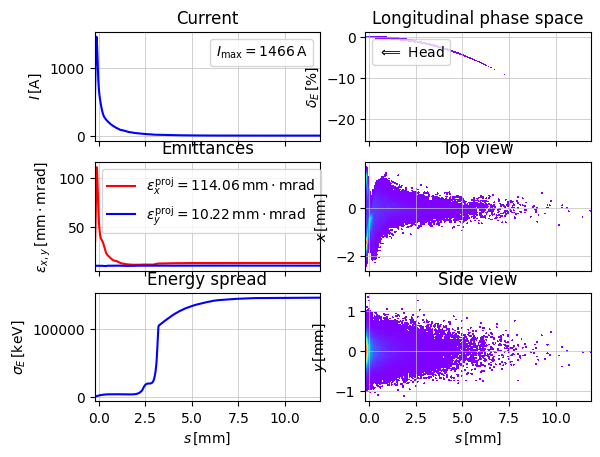

In [4]:
show_e_beam(p_array)

1.5361042457936593 rho= 16.361050285083245
1.81222 rho= 94.05668599377697
1.5491873961201 rho= 20.76086588894663
1.9060111581781 rho= 25.74722529536083
1.9060111581781 rho= 25.74722529536083
2.0340137 rho= 19.98198551849364
1.9060111581781 rho= 25.74722529536083
1.9060111581781 rho= 25.74722529536083
2.0340137 rho= 19.98198551849364
2.0340137 rho= 19.98198551849364
2.0340137 rho= 19.98198551849364
2.0340137 rho= 19.98198551849364
2.0340137 rho= 19.98198551849364
2.0856319020778 rho= 28.972582626548327
2.078583912105 rho= 21.571978536556724
2.078583912105 rho= 21.571978536556724
2.078583912105 rho= 21.571978536556724
2.078583912105 rho= 21.571978536556724
2.078583912105 rho= 21.571978536556724
2.078583912105 rho= 21.571978536556724
2.078583912105 rho= 21.571978536556724
2.078583912105 rho= 21.571978536556724
2.078583912105 rho= 21.571978536556724
2.078583912105 rho= 21.571978536556724
2.078583912105 rho= 21.571978536556724
2.078583912105 rho= 21.571978536556724
2.078583912105 rho= 21.57

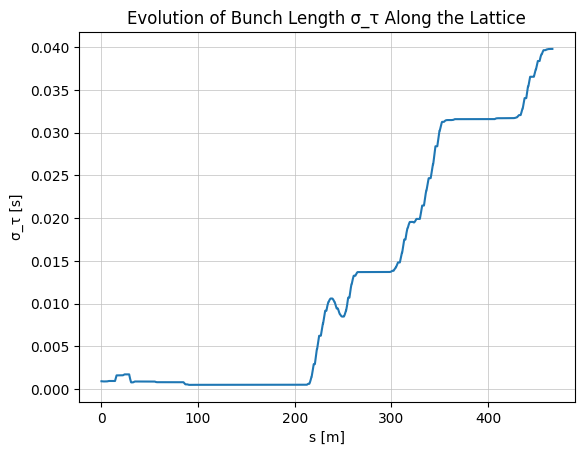

In [5]:
import time
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
from ocelot.cpbd.physics_proc import PhysProc

# Create the Navigator
navi = Navigator(lat)
navi.unit_step = 0.1  # high-resolution steps

for i in range(len(lat.sequence)-1):
    elem = lat.sequence[i]
    if isinstance(elem, SBend):
        # Estimate local bending radius
        if abs(elem.angle) > 0:
            rho = elem.l / abs(elem.angle)
            isr_proc = ISRBend(radius=rho)
            navi.add_physics_proc(isr_proc, elem, lat.sequence[i+1])


            print(elem.l,"rho=" ,rho)



# Define the hook as a physics process
class HookProcess(PhysProc):
    def __init__(self, sigma_tau_list):
        super().__init__()
        self.sigma_tau_list = sigma_tau_list

    def apply(self, p_array, step_size):
        sigma_tau = np.std(p_array.rparticles[4])
        self.sigma_tau_list.append(sigma_tau)
        print(f"s = {self.z0:.3f} m, σ_τ = {sigma_tau:.3e} s")

# Attach the custom hook process
sigma_tau_list = []
hook_proc = HookProcess(sigma_tau_list)
navi.add_physics_proc(hook_proc, lat.sequence[0], lat.sequence[-1])

# Track
p_array_t = deepcopy(p_array)
start = time.time()
tws_track, p_array_t = track(lat, p_array_t, navi)
print("\n time exec:", time.time() - start, "sec")

# Plot
print("sigma_tau_list length:", len(sigma_tau_list))
print("lat.totalLen:", lat.totalLen)

s_axis = np.linspace(0, lat.totalLen, len(sigma_tau_list))
plt.plot(s_axis, sigma_tau_list)
plt.xlabel("s [m]")
plt.ylabel("σ_τ [s]")
plt.title("Evolution of Bunch Length σ_τ Along the Lattice")
plt.grid(True)
plt.show()


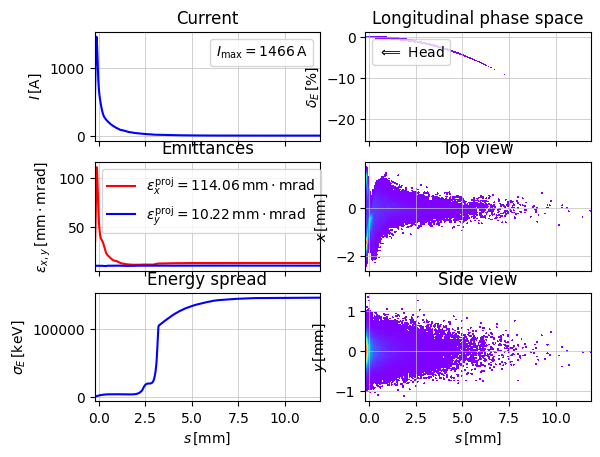

In [6]:
show_e_beam(p_array)

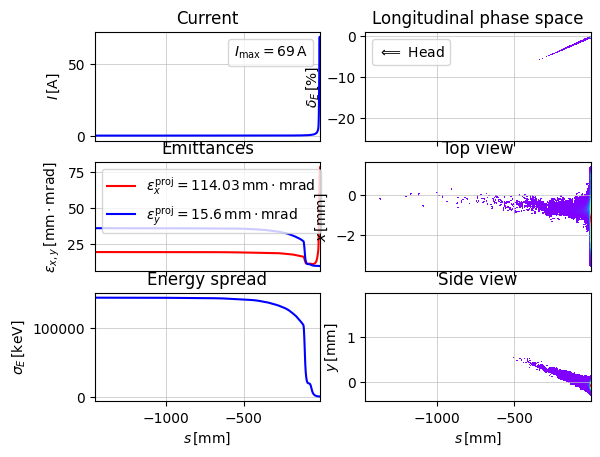

In [7]:
show_e_beam(p_array_t)



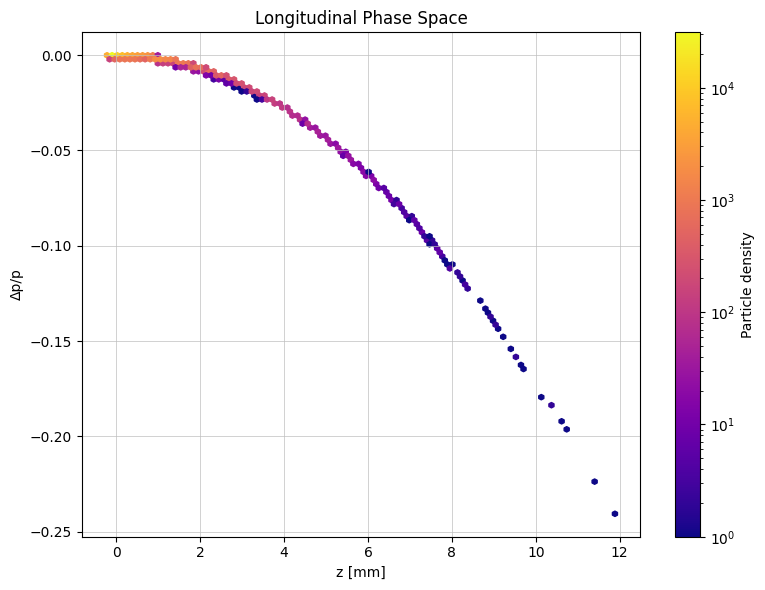

In [8]:
import matplotlib.pyplot as plt

# Longitudinal phase space: z vs. Δp/p
z = p_array.rparticles[4]   # in meters
dp_p = p_array  .rparticles[5]  # unitless

plt.figure(figsize=(8,6))
plt.hexbin(z * 1e3, dp_p, gridsize=100, cmap='plasma', bins='log')  # convert z to mm for better readability
plt.colorbar(label='Particle density')
plt.xlabel("z [mm]")
plt.ylabel("Δp/p")
plt.title("Longitudinal Phase Space")
plt.grid(True)
plt.tight_layout()
plt.show()

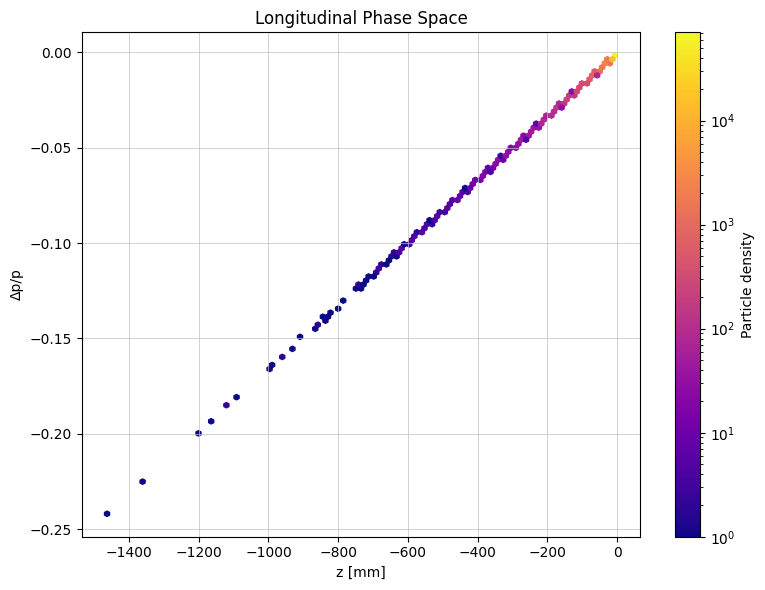

In [9]:
import matplotlib.pyplot as plt

# Longitudinal phase space: z vs. Δp/p
z = p_array_t.rparticles[4]   # in meters
dp_p = p_array_t.rparticles[5]  # unitless

plt.figure(figsize=(8,6))
plt.hexbin(z * 1e3, dp_p, gridsize=100, cmap='plasma', bins='log')  # convert z to mm for better readability
plt.colorbar(label='Particle density')
plt.xlabel("z [mm]")
plt.ylabel("Δp/p")
plt.title("Longitudinal Phase Space")
plt.grid(True)
plt.tight_layout()
plt.show()

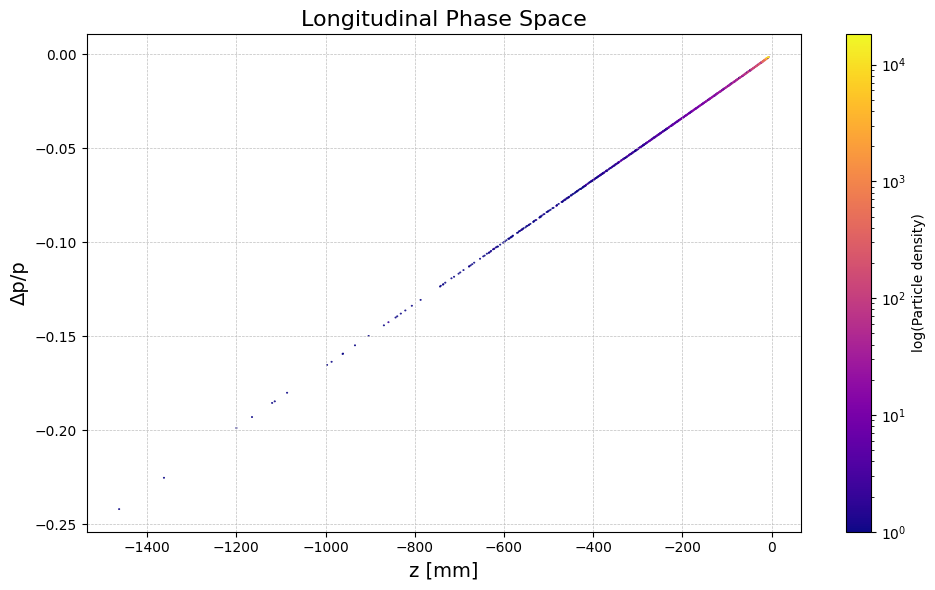

In [10]:
# Longitudinal phase space: z vs. Δp/p
z = p_array_t.rparticles[4]   # in meters
dp_p = p_array_t.rparticles[5]  # unitless

plt.figure(figsize=(10, 6))

hb = plt.hexbin(z * 1e3, dp_p, gridsize=1000, cmap='plasma', bins='log')  # log scale improves contrast
plt.colorbar(hb, label='log(Particle density)')

plt.xlabel("z [mm]", fontsize=14)
#plt.xlim(-1,2)
#plt.ylim(-0.02,0.02)
plt.ylabel("Δp/p", fontsize=14)
plt.title("Longitudinal Phase Space", fontsize=16)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [11]:
y = p_array_t.rparticles[1]  # in meters

plt.figure(figsize=(10, 6))
hb = plt.hexbin(z * 1e3, y * 1e3, gridsize=10000, cmap='viridis', bins='log')
plt.colorbar(hb, label='log(Particle density)')

plt.xlabel("z [mm]", fontsize=14)
plt.ylabel("y [mm]", fontsize=14)
plt.xlim(-20,0)
plt.title("Side View (y vs z)", fontsize=16)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

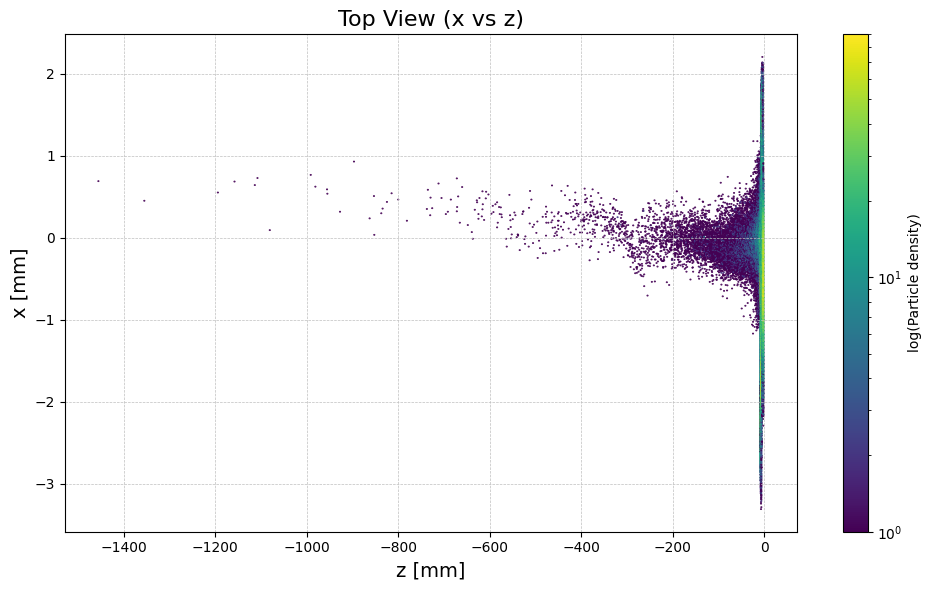

In [ ]:
x = p_array_t.rparticles[0]  # in meters

plt.figure(figsize=(10, 6))
hb = plt.hexbin(z * 1e3, x * 1e3, gridsize=1000, cmap='viridis', bins='log')
plt.colorbar(hb, label='log(Particle density)')

plt.xlabel("z [mm]", fontsize=14)
plt.ylabel("x [mm]", fontsize=14)
plt.title("Top View (x vs z)", fontsize=16)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


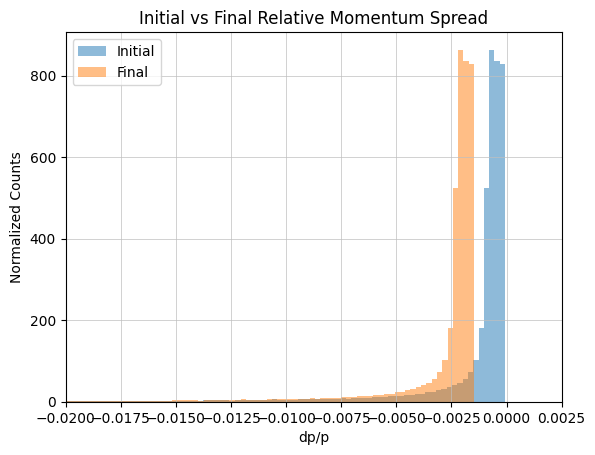

In [24]:
plt.hist(p_array.rparticles[5], bins=1000, alpha=0.5, label="Initial", density=True)
plt.hist(p_array_t.rparticles[5], bins=1000, alpha=0.5, label="Final", density=True)
plt.title("Initial vs Final Relative Momentum Spread")
plt.xlabel("dp/p")
plt.xlim(-0.02,0.0025)
plt.ylabel("Normalized Counts")
plt.legend()
plt.grid(True)
plt.show()
